In [1]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

main_color = 'steelblue'
dark_color = 'navy'
accent_color = 'orange'

In [2]:
path_df_cleaned = 'Data/meteo_pivoted_cleaned.parquet'

df = pd.read_parquet(path_df_cleaned)

In [3]:
df.columns

Index(['CO2', 'Hr', 'Hr_Trockner', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]',
       'RainDur', 'SO2', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'eBC2.5',
       'year', 'day', 'hour', 'day_of_week', 'month', 'season',
       'PM2.5_gap_too_long', 'PM2.5_was_interpolated', 'NOx_gap_too_long',
       'NOx_was_interpolated', 'NO_gap_too_long', 'NO_was_interpolated',
       'NO2_gap_too_long', 'NO2_was_interpolated', 'eBC2.5_gap_too_long',
       'eBC2.5_was_interpolated', 'PN[5-100nm]_gap_too_long',
       'PN[5-100nm]_was_interpolated', 'Hr_gap_too_long',
       'Hr_was_interpolated', 'Hr_Trockner_gap_too_long',
       'Hr_Trockner_was_interpolated', 'RainDur_gap_too_long',
       'RainDur_was_interpolated', 'StrGlo_gap_too_long',
       'StrGlo_was_interpolated', 'T_gap_too_long', 'T_was_interpolated',
       'T_Trockner_gap_too_long', 'T_Trockner_was_interpolated',
       'WD_gap_too_long', 'WD_was_interpolated', 'WVv_gap_too_long',
       'WVv_was_interpolated', 'wind_sector'],
    

Zurich Airport, Switzerland: A strict night-time curfew has been in force since 29 July 2010 between 23:30 and 6:00; the time between 23:00 and 23:30 may only be used to reduce backlogs of delayed flights.[1]

In [6]:
# create a binary feature for weekend
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [10]:
# create a nighttime feature - there are no flights during night allowed in Zurich
df['is_night'] = df['hour'].isin([0,1,2,3,4,5]).astype(int)

In [37]:
pollutants_columns = ['CO2', 'NO', 'NO2', 'NOx', 'PM2.5', 'PN[5-100nm]', 'SO2',  'eBC2.5']
weather_columns = ['Hr', 'Hr_Trockner', 'RainDur', 'StrGlo', 'T', 'T_Trockner', 'WD', 'WVv', 'wind_dir_x', 'wind_dir_y', 'wind_x', 'wind_y']
pollutants_remove_days = ['NO', 'NO2', 'NOx', 'PM2.5']
pollutants_interpolate = ['NO', 'NO2', 'NOx', 'PM2.5','eBC2.5', 'PN[5-100nm]']
pollutants_ignore = ['CO2', 'SO2']
time_features = ['year', 'day', 'hour', 'day_of_week', 'month', 'season','is_weekend']

In [13]:
# Convert degrees to radians
radians = np.deg2rad(df['WD'])

# Project onto unit circle
df['wind_dir_x'] = np.cos(radians)
df['wind_dir_y'] = np.sin(radians)

In [17]:
df['wind_x'] = df['WVv'] * np.cos(radians)
df['wind_y'] = df['WVv'] * np.sin(radians)

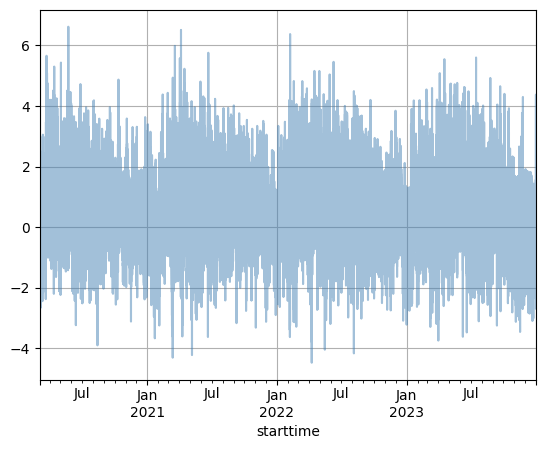

In [18]:
col = 'wind_x'
df[col].plot(alpha=0.5, label='Original data', color=main_color)

plt.grid(True)

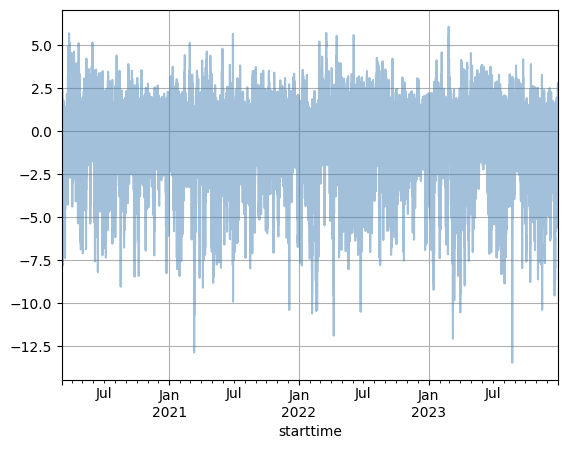

In [19]:
col = 'wind_y'
df[col].plot(alpha=0.5, label='Original data', color=main_color)

plt.grid(True)

In [28]:
def wind_direction_sector(degrees):
    dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
    return pd.cut(degrees % 360, bins=bins, labels=dirs, include_lowest=True, right=False)

df['wind_sector'] = wind_direction_sector(df['WD'])

In [39]:
df = pd.get_dummies(df, columns=['wind_sector'], drop_first=True)

In [31]:
# Create rolling 1- and 24-hour averages
# use mean for temperature, humidity
# for others use median - spiky

# keep track of the rolling average features, so we can see how correlated they are with each other later
# then decide which ones to keep
avg_col = []

for col in ['Hr', 'Hr_Trockner', 'T', 'T_Trockner', 'wind_dir_x', 'wind_dir_y', 'wind_x', 'wind_y']:
    df[col+'_1h_avg'] = df[col].rolling(window=6, min_periods=1).mean()
    df[col+'_24h_avg'] = df[col].rolling(window=144, min_periods=1).mean()
    avg_col = avg_col + [col+'_1h_avg', col+'_24h_avg']


for col in ['RainDur', 'StrGlo', 'WVv']:
    df[col+'_1h_avg'] = df[col].rolling(window=6, min_periods=1).median()
    df[col+'_24h_avg'] = df[col].rolling(window=144, min_periods=1).median()
    avg_col = avg_col + [col+'_1h_avg', col+'_24h_avg']

df['wind_speed_1h_med'] = df['WVv'].rolling(window=6, min_periods=1).median()
avg_col = avg_col + ['wind_speed_1h_med']
# use max to capture gusts
df['wind_speed_1h_max'] = df['WVv'].rolling(window=6, min_periods=1).max()
avg_col = avg_col + ['wind_speed_1h_max']

print(avg_col)


['Hr_1h_avg', 'Hr_24h_avg', 'Hr_Trockner_1h_avg', 'Hr_Trockner_24h_avg', 'T_1h_avg', 'T_24h_avg', 'T_Trockner_1h_avg', 'T_Trockner_24h_avg', 'wind_dir_x_1h_avg', 'wind_dir_x_24h_avg', 'wind_dir_y_1h_avg', 'wind_dir_y_24h_avg', 'wind_x_1h_avg', 'wind_x_24h_avg', 'wind_y_1h_avg', 'wind_y_24h_avg', 'RainDur_1h_avg', 'RainDur_24h_avg', 'StrGlo_1h_avg', 'StrGlo_24h_avg', 'WVv_1h_avg', 'WVv_24h_avg', 'wind_speed_1h_med', 'wind_speed_1h_max']


In [41]:
# check correlations
df[['PM2.5', 'NOx'] + avg_col].corr()


,PM2.5,NOx,Hr_1h_avg,Hr_24h_avg,Hr_Trockner_1h_avg,Hr_Trockner_24h_avg,T_1h_avg,T_24h_avg,T_Trockner_1h_avg,T_Trockner_24h_avg,wind_dir_x_1h_avg,wind_dir_x_24h_avg,wind_dir_y_1h_avg,wind_dir_y_24h_avg,wind_x_1h_avg,wind_x_24h_avg,wind_y_1h_avg,wind_y_24h_avg,RainDur_1h_avg,RainDur_24h_avg,StrGlo_1h_avg,StrGlo_24h_avg,WVv_1h_avg,WVv_24h_avg,wind_speed_1h_med,wind_speed_1h_max
PM2.5,1.000000,0.356232,0.039261,-0.009372,-0.210767,-0.246981,-0.197357,-0.210854,0.017618,0.019048,0.165781,0.287821,0.183518,0.327982,0.134722,0.237846,0.238155,0.342598,-0.159881,-0.095095,-0.002673,-0.088236,-0.249589,-0.286256,-0.249589,-0.260451
NOx,0.356232,1.000000,0.289497,0.246605,-0.226383,-0.257362,-0.361351,-0.342870,-0.130566,-0.129211,-0.090831,-0.108700,-0.009332,0.069504,-0.146352,-0.158424,0.016877,0.046301,0.001810,0.025666,-0.162297,-0.274690,-0.278366,-0.261089,-0.278366,-0.273612
Hr_1h_avg,0.039261,0.289497,1.000000,0.660951,0.039371,-0.002899,-0.545313,-0.296972,-0.251099,-0.174697,-0.179122,-0.176461,0.122545,-0.120955,-0.277127,-0.229006,0.070715,-0.105968,0.285961,0.165728,-0.595392,-0.450806,-0.371263,-0.119410,-0.371263,-0.364199
Hr_24h_avg,-0.009372,0.246605,0.660951,1.000000,-0.044920,-0.011201,-0.423497,-0.453447,-0.232827,-0.253012,-0.138159,-0.229885,-0.062516,-0.133968,-0.184367,-0.300137,-0.053362,-0.107057,0.182745,0.244723,-0.294310,-0.608599,-0.130703,-0.199795,-0.130703,-0.128281
Hr_Trockner_1h_avg,-0.210767,-0.226383,0.039371,-0.044920,1.000000,0.964240,0.739540,0.810153,0.023706,0.053882,-0.033964,-0.051638,-0.027191,-0.029509,-0.043404,-0.070610,-0.044898,-0.049470,0.049841,-0.015444,0.138246,0.321180,-0.065564,-0.157193,-0.065564,-0.044653
Hr_Trockner_24h_avg,-0.246981,-0.257362,-0.002899,-0.011201,0.964240,1.000000,0.744819,0.823495,0.042349,0.048327,-0.010014,-0.039332,-0.035151,-0.052468,-0.009836,-0.048566,-0.053659,-0.069882,0.016602,-0.004504,0.147261,0.314102,-0.033960,-0.121011,-0.033960,-0.016093
T_1h_avg,-0.197357,-0.361351,-0.545313,-0.423497,0.739540,0.744819,1.000000,0.910993,0.293249,0.258483,0.094550,0.076800,-0.087590,0.054672,0.140219,0.078433,-0.070358,0.032046,-0.105644,-0.101703,0.482913,0.607294,0.135340,-0.112025,0.135340,0.147999
T_24h_avg,-0.210854,-0.342870,-0.296972,-0.453447,0.810153,0.823495,0.910993,1.000000,0.254753,0.279787,0.074020,0.093293,0.000554,0.020777,0.089778,0.105125,-0.015706,-0.002949,-0.067511,-0.102974,0.281186,0.629395,0.006025,-0.064534,0.006025,0.020474
T_Trockner_1h_avg,0.017618,-0.130566,-0.251099,-0.232827,0.023706,0.042349,0.293249,0.254753,1.000000,0.917431,0.090577,0.108632,-0.000037,0.046845,0.104558,0.100101,0.013813,0.049386,-0.048422,-0.018618,0.196674,0.353707,0.037537,-0.032517,0.037537,0.041544
T_Trockner_24h_avg,0.019048,-0.129211,-0.174697,-0.253012,0.053882,0.048327,0.258483,0.279787,0.917431,1.000000,0.074871,0.115758,0.013906,0.036126,0.077497,0.112021,0.018433,0.037732,-0.041397,-0.027015,0.126136,0.365280,0.007132,-0.015009,0.007132,0.011233


In [44]:
for var in weather_columns:
    if var != 'WD':
        corr = df[[f'{var}_1h_avg', f'{var}_24h_avg']].corr().iloc[0, 1]
        print(f"{var}: corr. between 1h and 24h avg = {corr:.3f}")

Hr: corr. between 1h and 24h avg = 0.661
Hr_Trockner: corr. between 1h and 24h avg = 0.964
RainDur: corr. between 1h and 24h avg = 0.280
StrGlo: corr. between 1h and 24h avg = 0.346
T: corr. between 1h and 24h avg = 0.911
T_Trockner: corr. between 1h and 24h avg = 0.917
WVv: corr. between 1h and 24h avg = 0.491
wind_dir_x: corr. between 1h and 24h avg = 0.600
wind_dir_y: corr. between 1h and 24h avg = 0.474
wind_x: corr. between 1h and 24h avg = 0.613
wind_y: corr. between 1h and 24h avg = 0.606


In [40]:
df[['PM2.5', 'NOx'] + weather_columns].corr()

,PM2.5,NOx,Hr,Hr_Trockner,RainDur,StrGlo,T,T_Trockner,WD,WVv,wind_dir_x,wind_dir_y,wind_x,wind_y
PM2.5,1.000000,0.356232,0.035971,-0.208262,-0.155466,0.005670,-0.193630,0.017160,-0.122324,-0.229201,0.137717,0.167174,0.124676,0.225365
NOx,0.356232,1.000000,0.281037,-0.220248,0.001965,-0.135187,-0.353388,-0.120725,0.105024,-0.254461,-0.091178,-0.024790,-0.135427,0.007436
Hr,0.035971,0.281037,1.000000,0.041042,0.278856,-0.585037,-0.545369,-0.233497,-0.037217,-0.352113,-0.146295,0.117051,-0.248665,0.071543
Hr_Trockner,-0.208262,-0.220248,0.041042,1.000000,0.051045,0.137832,0.737301,0.019560,0.057958,-0.061234,-0.027882,-0.024589,-0.038600,-0.042476
RainDur,-0.155466,0.001965,0.278856,0.051045,1.000000,-0.169421,-0.102169,-0.045629,0.126838,0.080779,-0.128793,-0.140455,-0.120385,-0.150801
StrGlo,0.005670,-0.135187,-0.585037,0.137832,-0.169421,1.000000,0.477265,0.180344,0.091645,0.248576,0.167348,-0.171037,0.251377,-0.073830
T,-0.193630,-0.353388,-0.545369,0.737301,-0.102169,0.477265,1.000000,0.273538,0.068360,0.129737,0.078308,-0.082931,0.127112,-0.069310
T_Trockner,0.017160,-0.120725,-0.233497,0.019560,-0.045629,0.180344,0.273538,1.000000,-0.007328,0.032346,0.071267,0.000333,0.089054,0.012640
WD,-0.122324,0.105024,-0.037217,0.057958,0.126838,0.091645,0.068360,-0.007328,1.000000,0.223898,-0.112497,-0.842480,-0.156796,-0.695720
WVv,-0.229201,-0.254461,-0.352113,-0.061234,0.080779,0.248576,0.129737,0.032346,0.223898,1.000000,0.026328,-0.375197,0.180566,-0.557233


In [54]:
df_model = df.drop(columns=['CO2', 'NO', 'NO2', 'PN[5-100nm]', 'SO2',  'eBC2.5'])

In [55]:
for col in df_model.columns:
    if df_model[col].isna().sum() > 0:
        print(col,': ',df_model[col].isna().mean().round(4)*100)

Hr_Trockner :  0.26
T_Trockner :  0.26
Hr_Trockner1h_avg :  0.26
Hr_Trockner24h_avg :  0.19
T_Trockner1h_avg :  0.26
T_Trockner24h_avg :  0.19
Hr_Trockner_1h_avg :  0.26
Hr_Trockner_24h_avg :  0.19
T_Trockner_1h_avg :  0.26
T_Trockner_24h_avg :  0.19


In [57]:
df_model.shape

(201168, 103)

In [ ]:
# drop the remaining (very few) missing values

df_model = df_model.dropna()

In [59]:
df_model.shape

(200638, 103)

In [ ]:
target_col = 'PM2.5'

## Split data

In [78]:
df_model.columns

Index(['Hr', 'Hr_Trockner', 'NOx', 'PM2.5', 'RainDur', 'StrGlo', 'T',
       'T_Trockner', 'WD', 'WVv',
       ...
       'wind_sector_E', 'wind_sector_SE', 'wind_sector_S', 'wind_sector_SW',
       'wind_sector_W', 'wind_sector_NW', 'season_Spring', 'season_Summer',
       'season_Winter', 'dayofyear'],
      dtype='object', length=106)

In [77]:
df_model.select_dtypes(include='object').columns


Index(['day'], dtype='object')

In [71]:
df_model = pd.get_dummies(df_model, columns=['season'], drop_first=True)

In [79]:
feature_columns = [col for col in df_model.columns if col not in ['NOx', 'PM2.5']]

In [80]:
df_model['dayofyear'] = pd.to_datetime(df_model['day']).dt.dayofyear
feature_columns.append('dayofyear')
feature_columns.remove('day')

In [82]:
df_model[feature_columns].dtypes.value_counts()


float64    58
int64      30
bool       10
int32       6
Name: count, dtype: int64

In [84]:
target_col = 'PM2.5'

In [85]:
from sklearn.model_selection import train_test_split

X = df_model[feature_columns]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # no shuffle for time series
)


## Train a random forest model

In [87]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 2.604306335594923
RMSE: 3.4792578078842213
R²: 0.25155221587098187


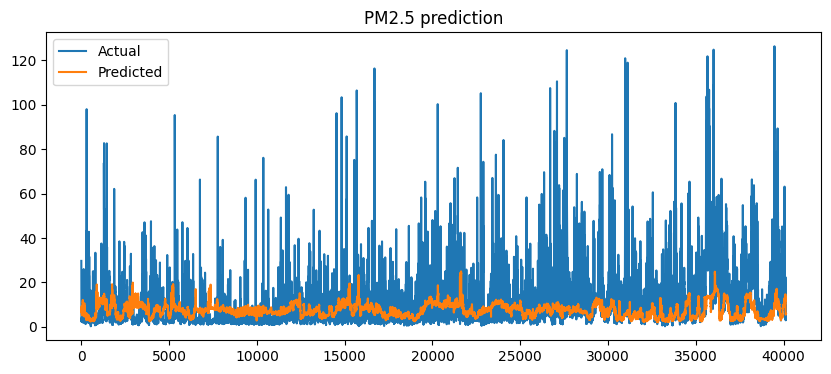

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('PM2.5 prediction')
plt.show()


## Predicting NOx

In [95]:
target_col = 'NOx'

In [2]:
from sklearn.model_selection import train_test_split

X = df_model[feature_columns]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # no shuffle for time series
)


NameError: name 'df_model' is not defined

## Train a random forest model

In [1]:
from sklearn.ensemble import RandomForestRegressor

model_NOx = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_NOx.fit(X_train, y_train)


NameError: name 'X_train' is not defined

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model_NOx.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 4.476129671714908
RMSE: 7.938721269089837
R²: 0.47003743648689567


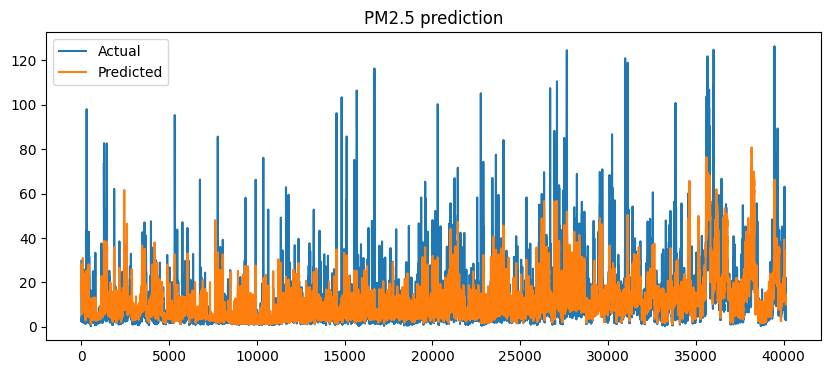

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('PM2.5 prediction')
plt.show()


In [101]:
df_model['NOx'].describe()

count    200638.000000
mean         11.738587
std          13.097624
min          -0.007394
25%           4.100119
50%           7.276701
75%          14.100000
max         211.932395
Name: NOx, dtype: float64

In [102]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Drop missing values just for target (not features — model handles those)
df_nox = df_model.dropna(subset=['NOx'])

X = df_nox[feature_columns]
y = df_nox['NOx']

# Train-test split (no shuffle because of time series)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model_gradient_boost_NOx = HistGradientBoostingRegressor(max_iter=100, random_state=42)
model_gradient_boost_NOx.fit(X_train, y_train)

# Predict
y_pred = model_gradient_boost_NOx.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MAE: 4.019
RMSE: 7.271
R²: 0.555


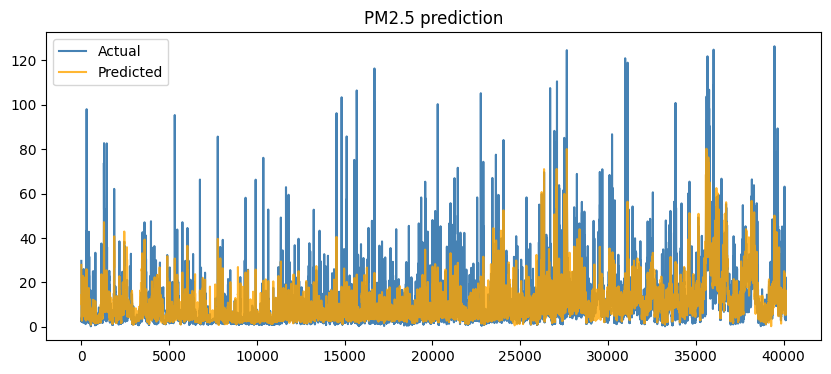

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', color=main_color)
plt.plot(y_pred, label='Predicted', color=accent_color, alpha=0.8)
plt.legend()
plt.title('PM2.5 prediction')
plt.show()

## Using lagged features

In [118]:
df_model['NOx_lag_1'] = df_model['NOx'].shift(1)
df_model['NOx_lag_6'] = df_model['NOx'].shift(6)
df_model['NOx_lag_12'] = df_model['NOx'].shift(12)
df_model['NOx_roll_1h'] = df_model['NOx'].shift(1).rolling(window=6, min_periods=1).mean()


In [ ]:
df_model_lagged = df_model.dropna(subset=['NOx', 'NOx_lag_1', 'NOx_lag_6', 'NOx_lag_12', 'NOx_roll_1h'])


In [125]:
lag_features = ['NOx_lag_1', 'NOx_lag_6', 'NOx_lag_12','NOx_roll_1h']
feature_columns += lag_features

In [126]:
feature_columns

['Hr',
 'Hr_Trockner',
 'RainDur',
 'StrGlo',
 'T',
 'T_Trockner',
 'WD',
 'WVv',
 'year',
 'hour',
 'day_of_week',
 'month',
 'PM2.5_gap_too_long',
 'PM2.5_was_interpolated',
 'NOx_gap_too_long',
 'NOx_was_interpolated',
 'NO_gap_too_long',
 'NO_was_interpolated',
 'NO2_gap_too_long',
 'NO2_was_interpolated',
 'eBC2.5_gap_too_long',
 'eBC2.5_was_interpolated',
 'PN[5-100nm]_gap_too_long',
 'PN[5-100nm]_was_interpolated',
 'Hr_gap_too_long',
 'Hr_was_interpolated',
 'Hr_Trockner_gap_too_long',
 'Hr_Trockner_was_interpolated',
 'RainDur_gap_too_long',
 'RainDur_was_interpolated',
 'StrGlo_gap_too_long',
 'StrGlo_was_interpolated',
 'T_gap_too_long',
 'T_was_interpolated',
 'T_Trockner_gap_too_long',
 'T_Trockner_was_interpolated',
 'WD_gap_too_long',
 'WD_was_interpolated',
 'WVv_gap_too_long',
 'WVv_was_interpolated',
 'is_weekend',
 'is_night',
 'wind_dir_x',
 'wind_dir_y',
 'wind_x',
 'wind_y',
 'Hr1h_avg',
 'Hr24h_avg',
 'Hr_Trockner1h_avg',
 'Hr_Trockner24h_avg',
 'T1h_avg',
 'T24h

In [127]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Drop missing values just for target (not features — model handles those)
df_nox = df_model.dropna(subset=['NOx'])

X = df_nox[feature_columns]
y = df_nox['NOx']

# Train-test split (no shuffle because of time series)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model_gradient_boost_NOx = HistGradientBoostingRegressor(max_iter=100, random_state=42)
model_gradient_boost_NOx.fit(X_train, y_train)

# Predict
y_pred = model_gradient_boost_NOx.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MAE: 1.810
RMSE: 3.857
R²: 0.875


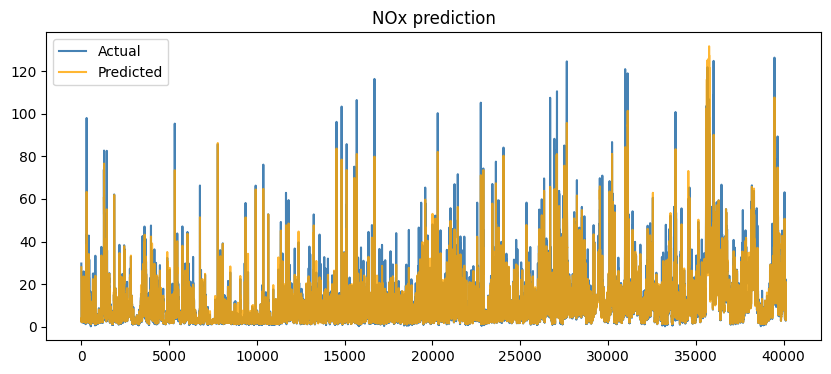

In [129]:

plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', color=main_color)
plt.plot(y_pred, label='Predicted', color=accent_color, alpha=0.8)
plt.legend()
plt.title('NOx prediction')
plt.show()